In [13]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'mathtext.default':  'regular' })
FONTSIZE = 13
plt.rcParams["font.family"] = "serif"

In [14]:
import numpy as np

with open("../EWF/marconi.txt", "r") as file:
    marconi_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/marconi.txt", "r") as file:
    marconi_wue= [float(line.strip()) for line in file if line.strip()]
    
with open("../EWF/fugaku.txt", "r") as file:
    fugaku_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/fugaku.txt", "r") as file:
    fugaku_wue= [float(line.strip()) for line in file if line.strip()]
    
with open("../EWF/polaris.txt", "r") as file:
    polaris_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/polaris.txt", "r") as file:
    polaris_wue= [float(line.strip()) for line in file if line.strip()]

with open("../EWF/frontier.txt", "r") as file:
    frontier_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/frontier.txt", "r") as file:
    frontier_wue= [float(line.strip()) for line in file if line.strip()]
    
with open("../CI/marconi.txt", "r") as file:
    ci_marconi= [float(line.strip()) for line in file if line.strip()]
with open("../CI/fugaku.txt", "r") as file:
    ci_fugaku= [float(line.strip()) for line in file if line.strip()]
with open("../CI/polaris.txt", "r") as file:
    ci_polaris= [float(line.strip()) for line in file if line.strip()]
with open("../CI/frontier.txt", "r") as file:
    ci_frontier= [float(line.strip()) for line in file if line.strip()]
    
wi_marconi  =[]
wi_fugaku  =[]
wi_polaris  =[]
wi_frontier  =[]
wsi_direct = [0.29, 0.36, 0.4237, 0.2716]
wsi_indirect = [0.29, 0.36, 0.39303875326672477, 0.2801834775358028]
for i in range(0,len(marconi_ewf)):
    wi_marconi.append(1.25*marconi_ewf[i]*(wsi_indirect[0]) + marconi_wue[i]*(wsi_direct[0]))
    wi_fugaku.append(1.4*fugaku_ewf[i]*(wsi_indirect[1]) + fugaku_wue[i]*(wsi_direct[1]))
    wi_polaris.append(1.65*polaris_ewf[i]*(wsi_indirect[2]) + polaris_wue[i]*(wsi_direct[2]))
    wi_frontier.append(1.05*frontier_ewf[i]*(wsi_indirect[3]) + frontier_wue[i]*(wsi_direct[3]))

wi = [wi_marconi, wi_fugaku, wi_polaris, wi_frontier]
ci = [ci_marconi, ci_fugaku, ci_polaris, ci_frontier]

wi_frontier = wi_frontier[:7]
ci_frontier = ci[3][:7]




/var/folders/38/_6s3q88d5fz9wnk2cl9lfgsr0000gn/T/ipykernel_99958/3273289934.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_yticklabels(time_label, fontsize=FONTSIZE)


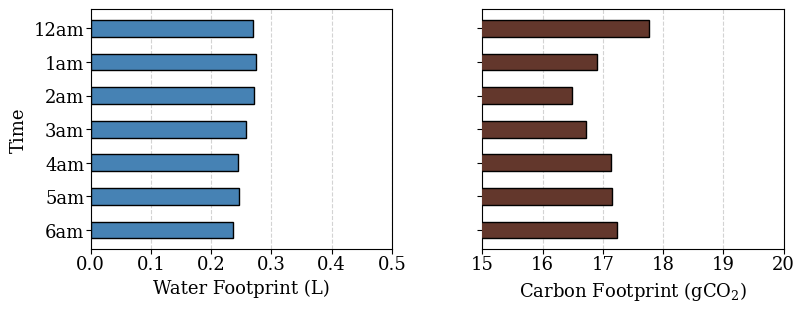

In [15]:
energy = 365034/3600/1000 #kwh
time_label = ["6am","5am","4am","3am","2am","1am","12am"]
water_frontier = [i*energy for i in wi_frontier]
water_frontier = water_frontier[::-1]
carbon_frontier = [i*energy for i in ci_frontier]
carbon_frontier = carbon_frontier[::-1]

fig, axs = plt.subplots(nrows=1, ncols=2, gridspec_kw={'hspace': 0.4, 'wspace': 0.3, 'bottom': 0.2, 
                    'top': 0.8, 'right':0.8, 'left':0.17}, figsize=(11,4),sharey=True)
x = range(7)
axs[0].set_yticklabels(time_label, fontsize=FONTSIZE)

axs[0].barh(x,water_frontier,height=0.5, color="#4682B4", edgecolor="black",zorder=3)
axs[0].grid(which='both', axis='x', color='lightgrey', ls='dashed', zorder=0)
axs[0].set_yticks(x)
axs[0].tick_params(axis='both', which='major', pad=1, labelsize=FONTSIZE)
axs[0].set_xlim(0, 0.5)
axs[0].set_xlabel("Water Footprint (L)", fontsize=FONTSIZE)
axs[0].set_ylabel("Time", fontsize=FONTSIZE)


axs[1].set_yticklabels(time_label, fontsize=FONTSIZE)
axs[1].barh(x,carbon_frontier,height=0.5, color="#63372C", edgecolor="black",zorder=3)
axs[1].grid(which='both', axis='x', color='lightgrey', ls='dashed', zorder=3)
axs[1].set_yticks(x)
axs[1].tick_params(axis='both', which='major', pad=1, labelsize=FONTSIZE)
axs[1].set_xlim(15, 20)
axs[1].set_xlabel("Carbon Footprint (gCO$_2$)", fontsize=FONTSIZE)

plt.savefig("../figures/figure13.pdf",bbox_inches='tight')
